1. I denna undersökning vill vi se om de två programmen ger samma genomsnittliga testreultat.
Våra hypoteser är:

Ho: Det finns ingen skillnad i testresultat för program A och program B.

Ha: Det finns en skillnad i testresultat mellan program A och program B.

Testet är tvåsidigt och genomförs med signifikansnivå 5%.

In [1]:
import numpy as np
# Sätt ert gruppnummer här (t.ex. 1, 2, 3, ...).
gruppnummer = 23
# Skapa en RNG med ert gruppnummer som seed
rng = np.random.default_rng(gruppnummer)
# Basvärden för testpoäng
# Program A: något lägre medelvärde, Program B: något högre
loc_A_bas = 72.0
loc_B_bas = 76.0
# Låt medelvärdena variera svagt med gruppnumret
# Variation ungefär ±2 poäng runt basvärdena
delta_A = (gruppnummer % 5 - 2) * 0.6 # -1.2 .. +1.2
delta_B = (gruppnummer % 7 - 3) * 0.5 # -1.5 .. +1.5
loc_A = loc_A_bas + delta_A
loc_B = loc_B_bas + delta_B
# Basstandardavvikelse för båda programmen
scale_A_bas = 8.0
scale_B_bas = 8.5
# Låt spridningen variera svagt med gruppnumret
scale_A = scale_A_bas + (gruppnummer % 3 - 1) * 0.5 # ~ 7.0 .. 9.0
scale_B = scale_B_bas + (gruppnummer % 4 - 1.5) * 0.4 # ~ 7.9 .. 9.1
# Säkerställ att scale aldrig blir för liten
scale_A = max(scale_A, 1.0)
scale_B = max(scale_B, 1.0)
print(f"Grupp {gruppnummer}:")
print(f" Program A: loc = {loc_A:.2f}, scale = {scale_A:.2f}")
print(f" Program B: loc = {loc_B:.2f}, scale = {scale_B:.2f}")
# Generera 25 testpoäng per program
program_A = rng.normal(loc=loc_A, scale=scale_A, size=25)
program_B = rng.normal(loc=loc_B, scale=scale_B, size=25)
# Avrunda till en decimal
program_A = np.round(program_A, 1)
program_B = np.round(program_B, 1)
# Klipp poäng till intervallet [0, 100]
program_A = np.clip(program_A, a_min=0.0, a_max=100.0)
program_B = np.clip(program_B, a_min=0.0, a_max=100.0)
print("Program A (testpoäng):")
print(program_A)
print("Program B (testpoäng):")
print(program_B)

Grupp 23:
 Program A: loc = 72.60, scale = 8.50
 Program B: loc = 75.50, scale = 9.10
Program A (testpoäng):
[77.3 74.4 72.1 52.9 76.3 54.5 80.3 77.8 79.7 79.6 75.1 68.1 70.  85.4
 67.7 70.7 66.4 68.2 70.  74.8 70.1 69.6 67.4 73.4 61.2]
Program B (testpoäng):
[ 76.   87.4  68.5  75.1 100.   66.5  60.7  71.6  91.9  94.   64.4  80.7
  75.5  70.1  57.8  84.8  67.7  78.2  76.2  92.5  86.2  65.   73.1  84.9
  63.4]


2. Variablerna Program A och Program B innehåller testresultat 0-100 poäng från två oberoende grupper av nyanställda som medverkat i två olika introduktionsprogram. Varje variabel har 25st testresultat.
Program A är ett traditionellt föreläsnings program.
Program B är ett interaktivt program baserat på diskussioner och uppgifter.

In [2]:
print("Datatyp Program A:", type(program_A))
print("Datatyp Program B:", type(program_B))

Datatyp Program A: <class 'numpy.ndarray'>
Datatyp Program B: <class 'numpy.ndarray'>


3. Som vi ser från koden ovan är variablerna program_A och program_B av datatypen: numpy.ndarray.
Varje element i respektive vektor representerar testresultatet för en persons test efter genomförd introduktion.
Grupperna är oberoende eftersom olika personer deltagit i olika program.

In [3]:
import pandas as pd

pd.DataFrame({
    "Program A": program_A,
    "Program B": program_B
}).describe()

,Program A,Program B
count,25.000000,25.000000
mean,71.320000,76.488000
std,7.546412,11.356728
min,52.900000,57.800000
25%,68.100000,67.700000
50%,70.700000,75.500000
75%,76.300000,84.900000
max,85.400000,100.000000


Medianen motsvarar 50-percentilen i tabellen ovan.

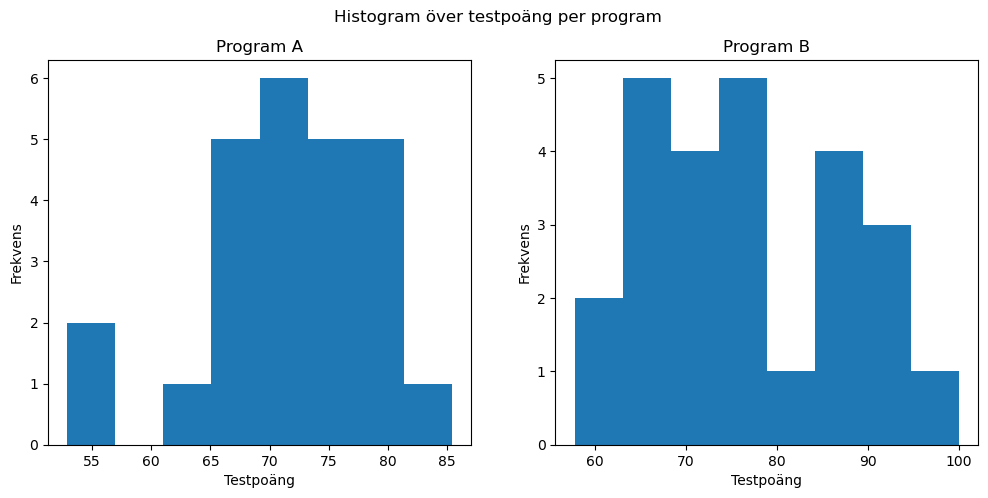

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(program_A, bins=8)
ax[0].set_title("Program A")
ax[0].set_xlabel("Testpoäng")
ax[0].set_ylabel("Frekvens")

ax[1].hist(program_B, bins=8)
ax[1].set_title("Program B")
ax[1].set_xlabel("Testpoäng")
ax[1].set_ylabel("Frekvens")

plt.suptitle("Histogram över testpoäng per program")

plt.show()

C:\Users\gimsb\AppData\Local\Temp\ipykernel_6744\3934055887.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([program_A, program_B], labels=["Program A", "Program B"])


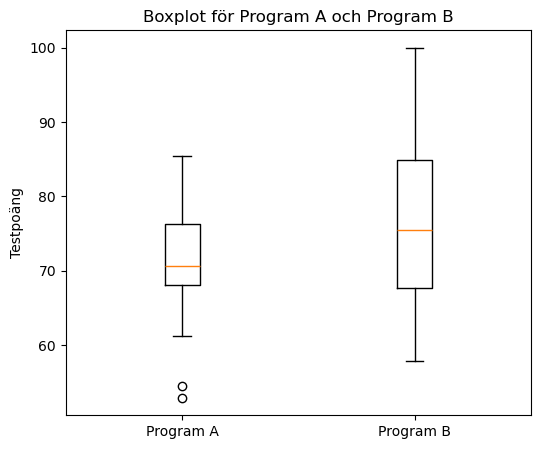

In [5]:
# Diagram 2: boxplot
plt.figure(figsize=(6,5))
plt.boxplot([program_A, program_B], labels=["Program A", "Program B"])
plt.ylabel("Testpoäng")
plt.title("Boxplot för Program A och Program B")
plt.show()

5.  Medelvärdet är ungefär 5 poäng högre för program B. Men program B har även en större spridning än program A. 
Vi kan därför inte avgöra en statistisk skillnad utifrån medelvärdena. 

In [6]:
from scipy.stats import ttest_ind
from scipy import stats

# Genomför t-testet. Vi använder Welch's t-test pga skilnnader i gruppernas varians.

t_stat, p_value = ttest_ind(program_A, program_B, equal_var=False)

# Skriver ut p och t-värdet.

print(f"t-värde = {t_stat:.3f}")
print(f"p-värde = {p_value:.5f}")

# Medelvärden
mean_A = np.mean(program_A)
mean_B = np.mean(program_B)

print(f"Medelvärde Program A = {mean_A:.2f}")
print(f"Medelvärde Program B = {mean_B:.2f}")

# Medelvärde A - medelvärde B.

diff = mean_A - mean_B

# Beräknar standardfelet

se = np.sqrt(
    np.var(program_A, ddof=1)/len(program_A)
    +
    np.var(program_B, ddof=1)/len(program_B)
)

# Beräknar frihetsgrader.

df = (
    (np.var(program_A, ddof=1)/len(program_A)
     +
     np.var(program_B, ddof=1)/len(program_B))**2
) / (
    ((np.var(program_A, ddof=1)/len(program_A))**2)/(len(program_A)-1)
    +
    ((np.var(program_B, ddof=1)/len(program_B))**2)/(len(program_B)-1)
)

# Hämta kritiskt t-värde.

t_crit = stats.t.ppf(0.975, df)

# Beräknar KI intervallet.

ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"95% KI för skillnaden (A − B): [{ci_low:.3f}, {ci_high:.3f}]")

# Beslut
alpha = 0.05

if p_value < alpha:
    print("Vi förkastar H0")
else:
    print("Vi förkastar inte H0")

t-värde = -1.895
p-värde = 0.06502
Medelvärde Program A = 71.32
Medelvärde Program B = 76.49
95% KI för skillnaden (A − B): [-10.672, 0.336]
Vi förkastar inte H0


9. Eftersom p-värdet 0,064 är större än signifikansnivån 0,05 förkastar vi ej Ho. 
Det betyder att vi inte ser en tillräckligt stor statistisk skillnad mellan programmens olika resultat.

10. Program B hade ett något högre medelvärde, men eftersom skillnaden inte är statistiskt signifikant, kan inte HR-avdelningen med säkerhet säga att program B ger ett bättre genomsnittligt resultat än program A baserat på detta stickprov.